In [5]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [6]:
# it hold the conversation history 
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder= StateGraph(State)

In [7]:
graph_builder

In [8]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model
llm = ChatGroq(model="openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002D9688D92B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002D9688D9D30>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [10]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}  # here it is a node(worker returning the new response)

In [11]:
graph_builder= StateGraph(State)
graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot") #it is edge which tell the flow or direction
graph_builder.add_edge("llmchatbot",END)

graph =graph_builder.compile()


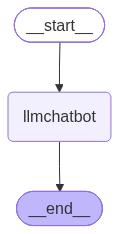

In [12]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
    pass


In [13]:
response = graph.invoke({"messages":"who is salmaan khan?"})
response["messages"][-1].content

'Salman\u202fKhan (often spelled **Salmaan\u202fKhan**) is one of the most famous and influential figures in the Indian film industry, particularly in Bollywood. Here are the key points about him:\n\n| Aspect | Details |\n|--------|---------|\n| **Full Name** | Abdul\u202fSalman\u202fKhan |\n| **Born** | 27\u202fDecember\u202f1965, Indore, Madhya Pradesh, India |\n| **Profession** | Actor, film producer, singer, television host, philanthropist |\n| **Industry** | Bollywood (Hindi‑language cinema) |\n| **Debut Film** | *Biwi\u202fHo\u202fTo\u202fBadi* (1992) – a minor role; his first major hit was *Maine\u202fPyaar\u202fKiya* (1995) |\n| **Signature Movies** | • *Hum\u202fAapke\u202fHain\u202fKoun…!* (1994) <br>• *Karan\u202fArjun* (1995) <br>• *Hum\u202fDil\u202fDe\u202fChuke\u202fSanam* (1999) <br>• *Taal* (1999) <br>• *Dabangg* series (2010‑2021) <br>• *Bajrangi\u202fBhaijaan* (2015) <br>• *Tiger\u202fZinda\u202fHai* (2017) <br>• *Radhe* (2021) |\n| **Box‑Office Impact** | Consistent

Chatbot With Tool(Tavily)

In [14]:
from langchain_tavily import TavilySearch

tool= TavilySearch(max_results=2)
tool.invoke("who is dhanda nyoliwala?")

{'query': 'who is dhanda nyoliwala?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://genius.com/artists/Dhanda-nyoliwala',
   'title': 'Dhanda Nyoliwala Lyrics, Songs, and Albums | Genius',
   'content': '# Dhanda Nyoliwala\n\n### About Dhanda Nyoliwala\n\nDhanda Nyoliwala, a name synonymous with Haryanvi rap, brings the heat with his versatility, unapologetic lyrics, and iconic status. Originally from Nyoli Kalan, Haryana, India, this Australia-based artist exploded onto the scene in 2019. Fusing West Coast vibes with his native Haryanvi flow in his debut track “AFGAN,” Dhanda pioneered a game-changing sound – Haryanvi Drill. His genre-defining work paved the way for a new wave of Haryanvi artists. “UP TO U” smashed records, hitting #1 on both Spotify and Shazam India charts, cementing Dhanda’s legacy in Haryanvi rap.\n\nHttps%3a%2f%2fimages.genius.com%2fcc3baffa652d3447866ff768faf8e4a3.300x300x1\n\n### Big Plans\n\nHttps%3a%2f%2fimages.gen

# imp Doc string example 
when we bind it with llm or tool, llm will understand what tool will able to do

In [35]:
def multiply(a: int, b: int) -> int:
    """multiply a and b 

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: Output int
    """
    

In [36]:
tools= [tool,multiply]


In [37]:
llm_with_tool=llm.bind_tools(tools)

In [38]:
llm_with_tool

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.5.0', 'langchain': '1.3.14', 'langchain-openai': '1.4.2'}}, output_version=None, client=<openai.resources.chat.completions.completions.Completions object at 0x000002D96C2E7610>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002D96C2E7890>, root_client=<openai.OpenAI object at 0x000002D96C2E5450>, root_async_client=<openai.AsyncOpenAI object at 0x000002D96C2E6D50>, model_name='nvidia/nemotron-3-ultra-550b-a55b:free', model_kwargs={}, openai_api_key=SecretStr('**********'), openai_api_base='https://openrouter.ai/api/v1', openai_proxy=None, stream_chunk_timeout=120.0), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced se

# simple nemotron


In [1]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv("../.env")

# Initialize model pointing to OpenRouter
llm = ChatOpenAI(
    model="nvidia/nemotron-3-ultra-550b-a55b:free",
    openai_api_key=os.getenv("Nvidia_API_Key"),
    openai_api_base="https://openrouter.ai/api/v1"
)

# 1-Line simple chat!
response = llm.invoke("Who is Dhanda Nyoliwala?")
print(response.content)


**Dhanda Nyoliwala** (often stylized as **Dhanda Nyoli Wala**) is a popular **Haryanvi singer, rapper, and lyricist** from Haryana, India.

Here are the key details about him:

*   **Real Name:** His first name is **Dhanda**; "Nyoliwala" denotes his native village, **Nyoli** (in Hisar district, Haryana). It is a common practice in the Haryanvi music industry for artists to adopt their village name as a surname/stage name.
*   **Genre:** He is a leading figure in the **Haryanvi Hip-Hop / Desi Rap** scene, known for mixing traditional Haryanvi folk elements (like the *been* or *dhol* sounds) with modern trap and hip-hop beats.
*   **Breakthrough & Major Hits:** He gained massive popularity around 2020–2021. His most famous tracks include:
    *   **"Up To U"** (His breakout hit, hundreds of millions of views).
    *   **"No Mercy"**
    *   **"Afghan"**
    *   **"Jaatni"**
    *   **"Provider"**
    *   **"System"**
    *   **"Khatarnak"**
*   **Style:** He is known for his aggressive f

In [ ]:
# stategraph

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# node defination
def tool_calling_llm(state: State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm",)
builder.add_node("tools",ToolNode(tools))

# add edges
